In [ ]:
# 한글 깨짐 방지
!pip install koreanize-matplotlib

In [ ]:
# 필요 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# csv 파일 불러오고 데이터 확인
health_data = pd.read_csv("/content/smoking_health_data_preprocessed_v1.csv")
health_data.columns = [c.strip() for c in health_data.columns]    # 컬럼명 앞뒤 공백 제거

print(health_data.shape)    # (7000, 31)
print(health_data.info())
print("\n-----------------------------------------------------------------------------")
print(health_data.describe())

(7000, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   raw_id               7000 non-null   object 
 1   age                  7000 non-null   int64  
 2   height_cm            7000 non-null   int64  
 3   weight_kg            7000 non-null   int64  
 4   bmi                  7000 non-null   float64
 5   sight                7000 non-null   float64
 6   cavity               7000 non-null   int64  
 7   fasting_blood_sugar  7000 non-null   float64
 8   bp                   7000 non-null   float64
 9   triglyceride         7000 non-null   float64
 10  creatinine           7000 non-null   float64
 11  cholesterol          7000 non-null   int64  
 12  hdl                  7000 non-null   int64  
 13  ldl                  7000 non-null   int64  
 14  hemoglobin           7000 non-null   float64
 15  proteinuria          7000 n

In [ ]:
# 시각화 파일 불러오기
import sys
sys.path.append("/content/smoke_viz.py")
from smoke_viz import *

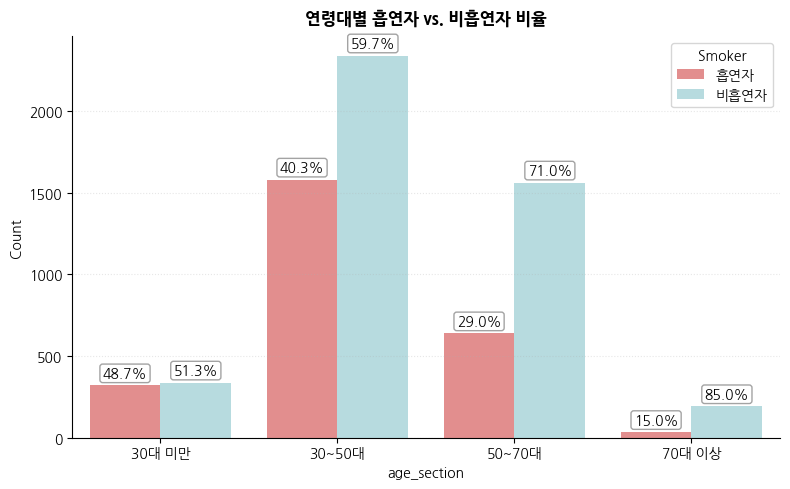

In [ ]:
order = ["30대 미만", "30~50대", "50~70대", "70대 이상"]

countplot_feature_smoke(
    health_data,
    x="age_section",
    hue="Smoker",
    order=order,
    title="연령대별 흡연자 vs. 비흡연자 비율",
    palette=SMOKER_PALETTE
)

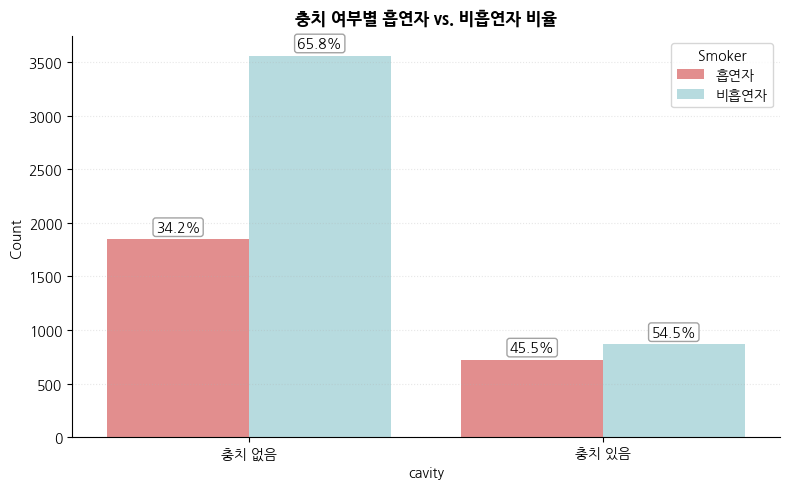

In [ ]:
# 충치 여부에 따른 흡연자 비율
df = health_data.copy()
df['cavity'] = df['cavity'].replace({0: '충치 없음', 1: '충치 있음'})
order = ["충치 없음", "충치 있음"]

countplot_feature_smoke(
    df,
    x="cavity",
    hue="Smoker",
    order=order,
    title="충치 여부별 흡연자 vs. 비흡연자 비율",
    palette=SMOKER_PALETTE
)

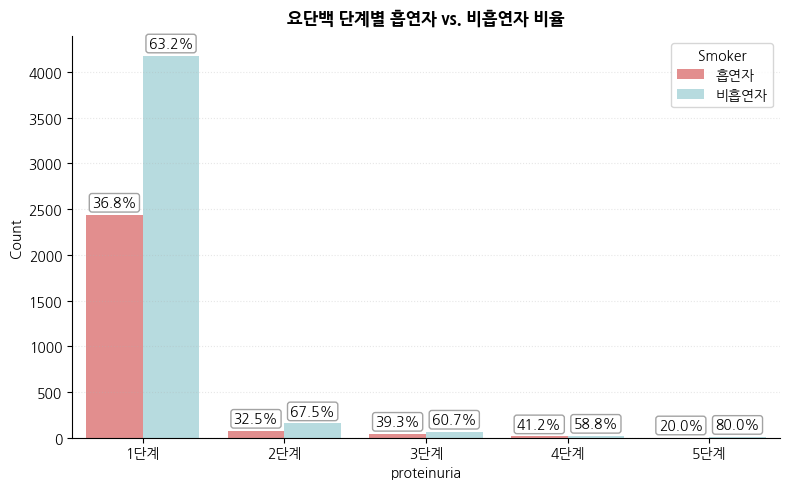

In [ ]:
# 충치 여부에 따른 흡연자 비율
df = health_data.copy()
df['proteinuria'] = df['proteinuria'].replace({1: '1단계', 2: '2단계', 3: '3단계', 4: '4단계', 5: '5단계'})
order = ['1단계', '2단계', '3단계', '4단계', '5단계']

countplot_feature_smoke(
    df,
    x="proteinuria",
    hue="Smoker",
    order=order,
    title="요단백 단계별 흡연자 vs. 비흡연자 비율",
    palette=SMOKER_PALETTE
)

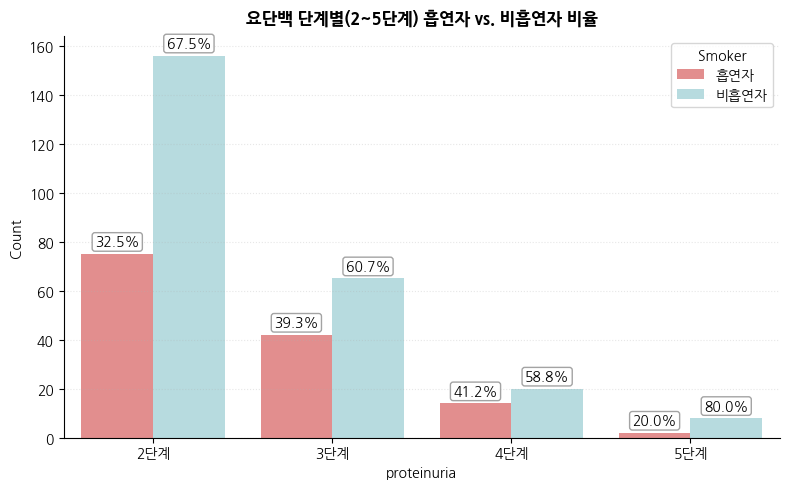

In [ ]:
# 뇨단백 경미한 그룹(1)제거 후 그래프
df_1 = health_data.copy()
protein_abnormal = df_1[df_1["proteinuria"] != 1]
protein_abnormal['proteinuria'] = protein_abnormal['proteinuria'].replace({2: '2단계', 3: '3단계', 4: '4단계', 5: '5단계'})
order = ['2단계', '3단계', '4단계', '5단계']

countplot_feature_smoke(
    protein_abnormal,
    x="proteinuria",
    hue="Smoker",
    order=order,
    title="요단백 단계별(2~5단계) 흡연자 vs. 비흡연자 비율",
    palette=SMOKER_PALETTE
)

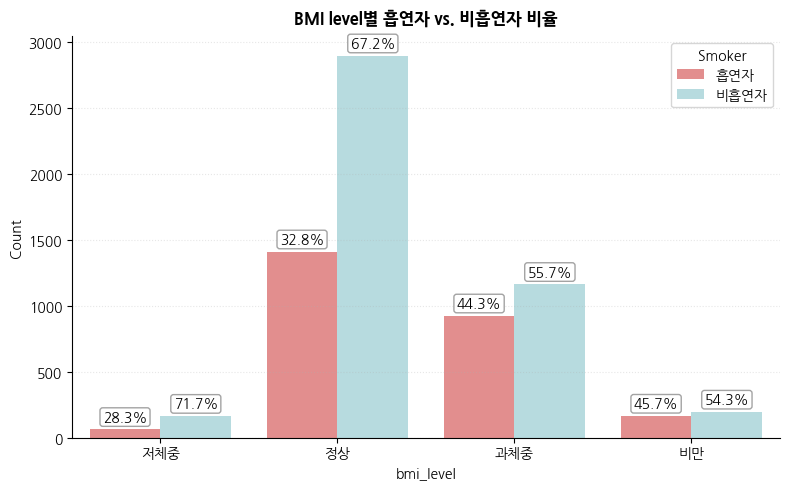

In [ ]:
# bmi에 따른 흡연자 수
order = ["저체중", "정상", "과체중", "비만"]

countplot_feature_smoke(
    health_data,
    x="bmi_level",
    hue="Smoker",
    order=order,
    title="BMI level별 흡연자 vs. 비흡연자 비율",
    palette=SMOKER_PALETTE
)

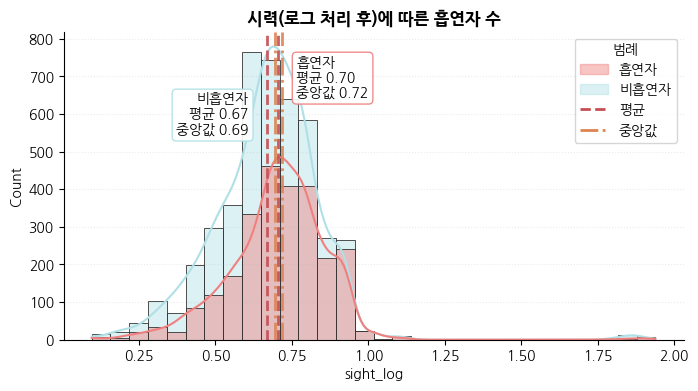

In [ ]:
# 시력(로그처리 후)에 따른 흡연자 수
hist_with_hue(health_data, 'sight_log', "시력(로그 처리 후)에 따른 흡연자 수", hue="Smoker", bins=30)

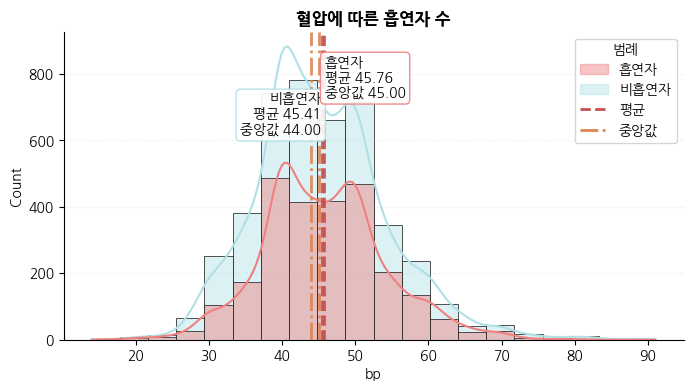

In [ ]:
# 혈압에 따른 흡연자 수
hist_with_hue(health_data, 'bp', "혈압에 따른 흡연자 수", hue="Smoker", bins=20)

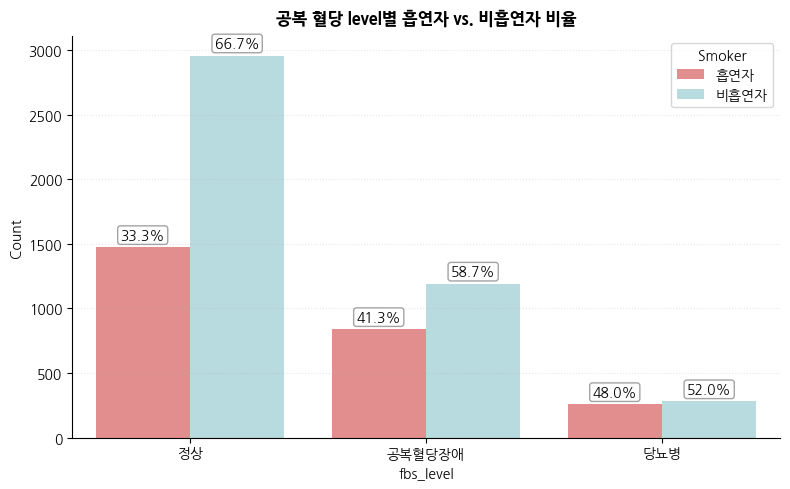

In [ ]:
# fbs_level별 흡연자 수
order = ["정상", "공복혈당장애", "당뇨병"]

countplot_feature_smoke(
    health_data,
    x="fbs_level",
    hue="Smoker",
    order=order,
    title="공복 혈당 level별 흡연자 vs. 비흡연자 비율",
    palette=SMOKER_PALETTE
)

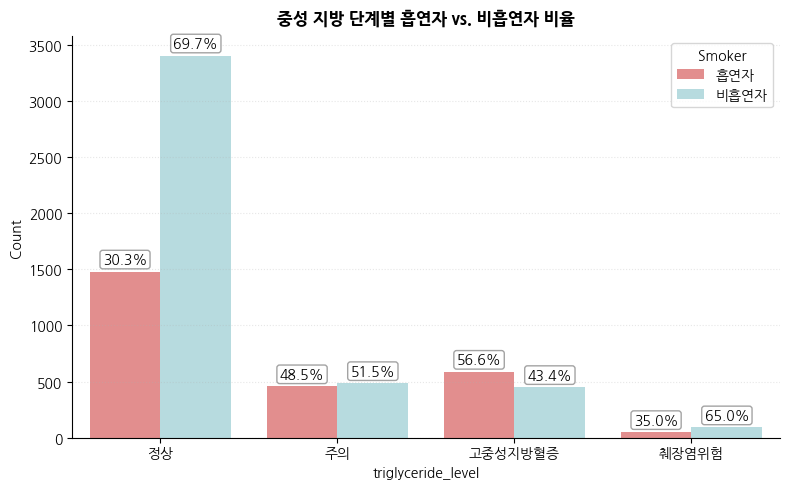

In [ ]:
# 중성지방 단계별 흡연자 수
order = ["정상", "주의", "고중성지방혈증", "췌장염위험"]

countplot_feature_smoke(
    health_data,
    x="triglyceride_level",
    hue="Smoker",
    order=order,
    title="중성 지방 단계별 흡연자 vs. 비흡연자 비율",
    palette=SMOKER_PALETTE
)

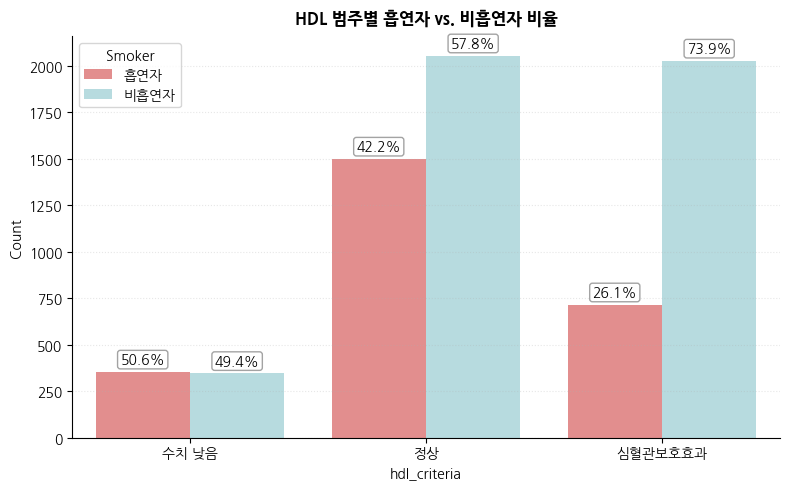

In [ ]:
# hdl 범주별 흡연자 수
order = ["수치 낮음", "정상", "심혈관보호효과"]

countplot_feature_smoke(
    health_data,
    x="hdl_criteria",
    hue="Smoker",
    order=order,
    title="HDL 범주별 흡연자 vs. 비흡연자 비율",
    palette=SMOKER_PALETTE
)

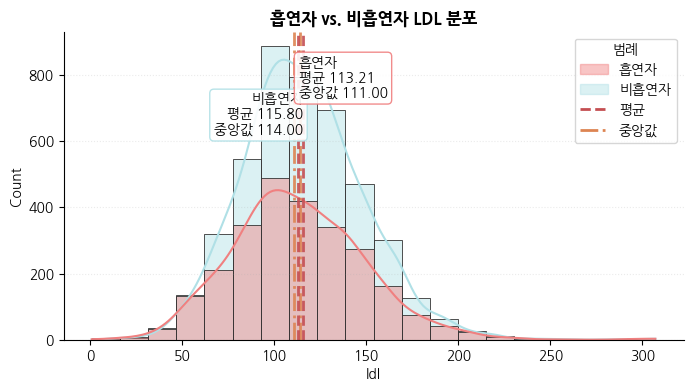

In [ ]:
# ldl별 흡연자 수
hist_with_hue(health_data, 'ldl', "흡연자 vs. 비흡연자 LDL 분포", hue="Smoker", bins=20)

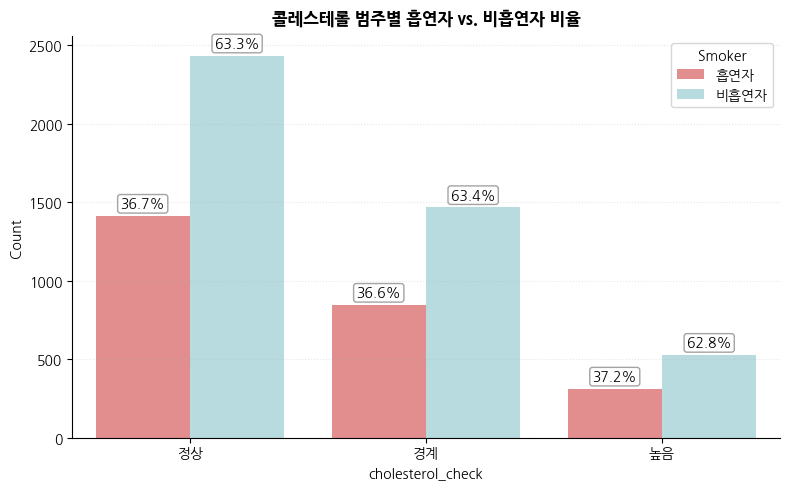

In [ ]:
# cholesterol 범주별 흡연자 수
order = ["정상", "경계", "높음"]

countplot_feature_smoke(
    health_data,
    x="cholesterol_check",
    hue="Smoker",
    order=order,
    title="콜레스테롤 범주별 흡연자 vs. 비흡연자 비율",
    palette=SMOKER_PALETTE
)

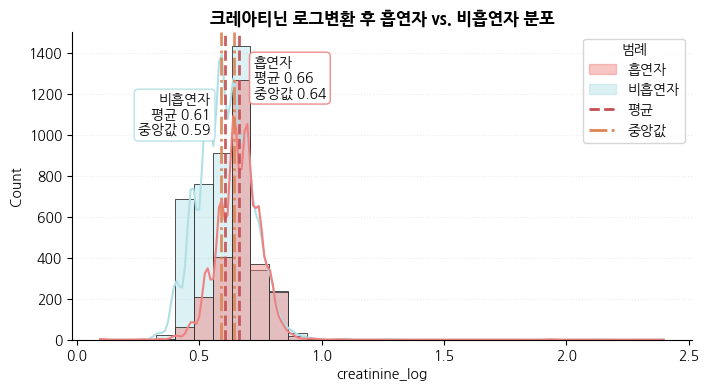

In [ ]:
# creatinine(로그 변환 후)과 흡연여부
hist_with_hue(health_data, 'creatinine_log', "크레아티닌 로그변환 후 흡연자 vs. 비흡연자 분포", hue="Smoker", bins=30)

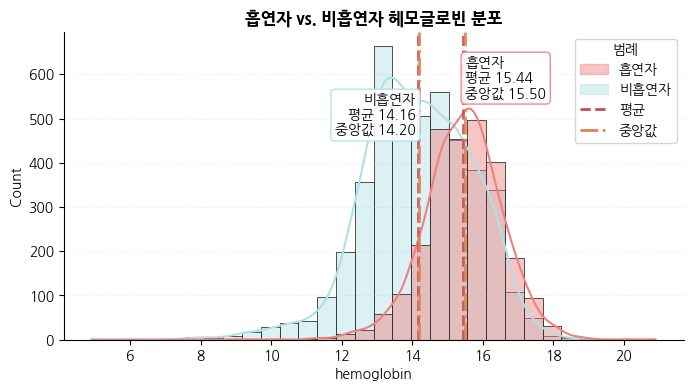

In [ ]:
# Hemoglobin과 흡연여부
hist_with_hue(health_data, 'hemoglobin', "흡연자 vs. 비흡연자 헤모글로빈 분포", hue="Smoker", bins=30)

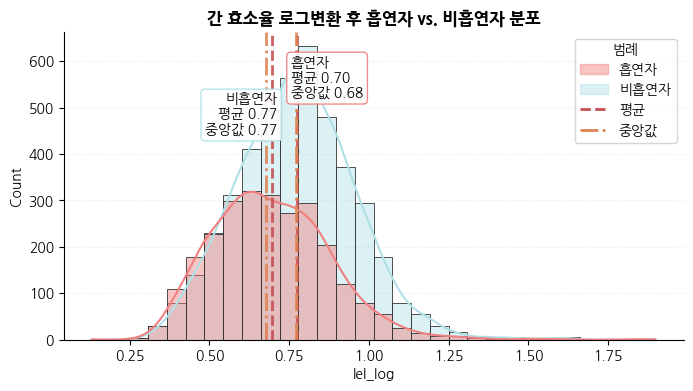

In [ ]:
# 간 효소율(로그 변환 후)과 흡연여부
hist_with_hue(health_data, 'lel_log', "간 효소율 로그변환 후 흡연자 vs. 비흡연자 분포", hue="Smoker", bins=30)

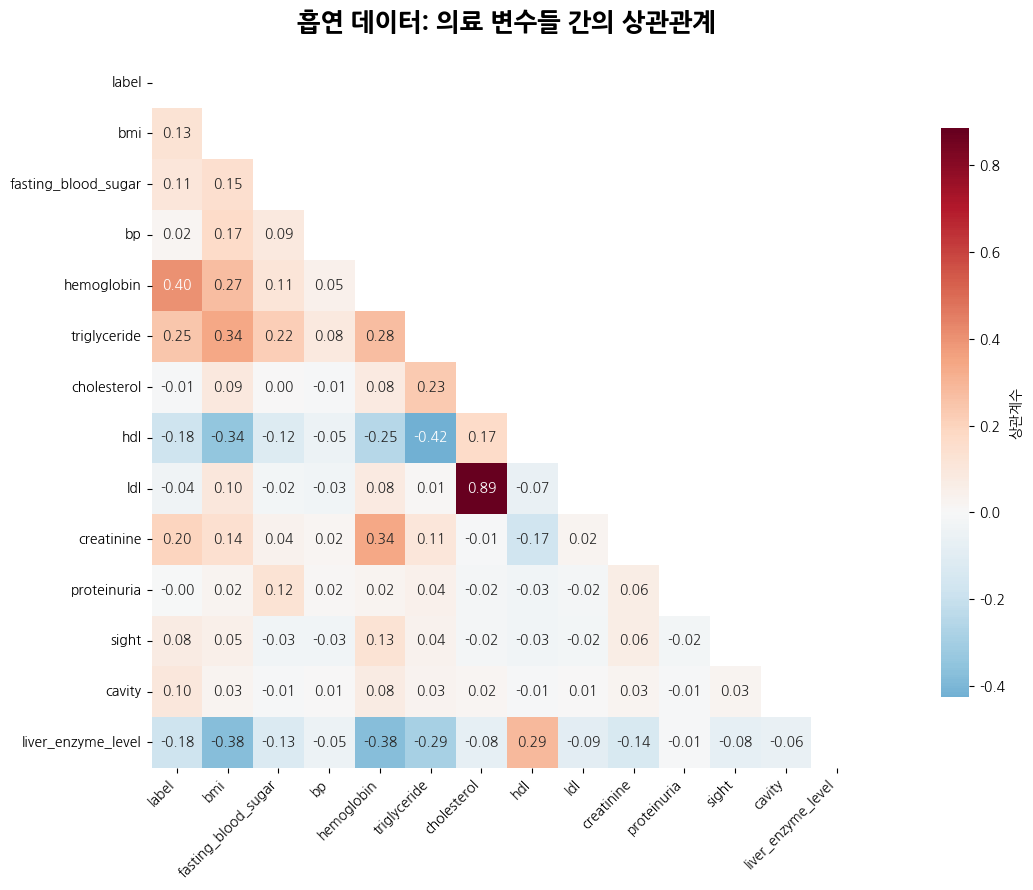

In [ ]:
# 히트맵 차트

# 상관계수 구하기
smoke_vars = [
    "label",
    "bmi", "fasting_blood_sugar", "bp", "hemoglobin",
    "triglyceride", "cholesterol", "hdl", "ldl",
    "creatinine", "proteinuria",
    "sight", "cavity", "liver_enzyme_level"
]

correlation_matrix = health_data[smoke_vars].corr() # 피어슨 상관계수 계산

# 히트맵 그리기
plt.figure(figsize=(16, 9))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # 상삼각 마스킹

sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'label': '상관계수', 'shrink': 0.8})

plt.title("흡연 데이터: 의료 변수들 간의 상관관계", fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()